In [9]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\outlet\Desktop\Programas\1 - Python\0 - Directorio de trabajo 1 en Python - 1
['0 - Setear el directorio (Anaconda) y otros comandos.txt', '20162019.xlsx', '20192023.xlsx', '2022.xlsx', '20232025.xlsx', '2025.xlsx', 'Arg PIB pc', 'calculadora.py', 'estadisticos_descriptivos_ordenados.xlsx', 'IA.py', 'mi_grafico.png', 'mpd2023_web.xlsx', 'pwt62_cleaned_step2.xlsx', 'pwt62_cleaned_step3.xlsx', 'pwt62_cleaned_step4.xlsx', 'pwt62_cleaned_step6.xlsx', 'pwt62_cleaned_step7.xlsx', 'pwt62_cleaned_step7v2.xlsx', 'pwt62_data.xlsx', 'RESUMEN-V2.xlsx', 'RESUMEN-V4.xlsx', 'RESUMEN.xlsx', 'RESUMENMENSUAL.xlsx', 'RESUMENMENSUALLOCAL.xlsx', 'setear y ver el directorio.py', 'Untitled-1.py']




BALASSA-SAMUELSON MODEL
                            OLS Regression Results                            
Dep. Variable:               lnRER_it   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     51.61
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.52e-96
Time:                        19:52:56   Log-Likelihood:                -1044.0
No. Observations:                1509   AIC:                             2112.
Df Residuals:                    1497   BIC:                             2176.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept   

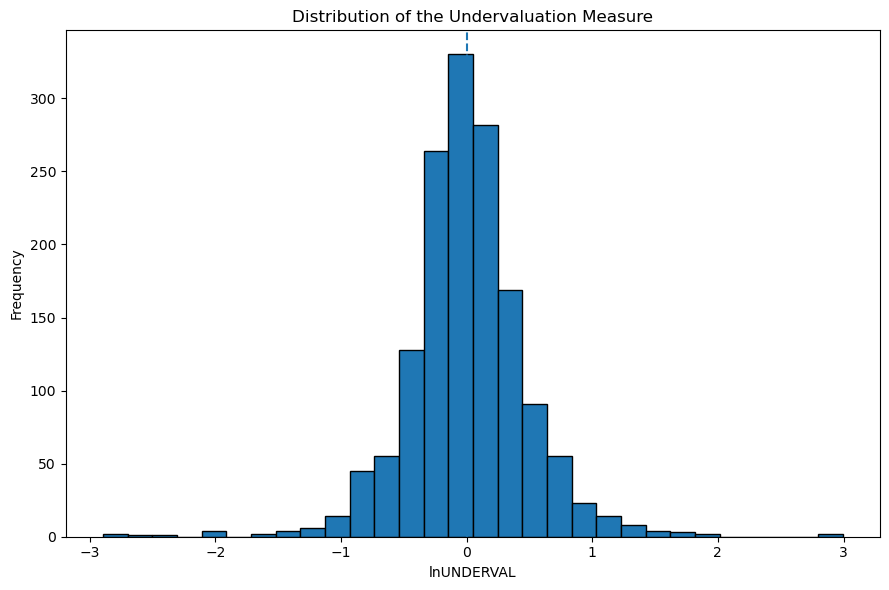



TABLE 1 — RODRIK (2008)
   Model  lnRGDPCH_it_1  SE lnRGDPCH_it_1  lnUNDERVAL_it  SE lnUNDERVAL_it  Interaction  SE Interaction  Observations  R-squared
Column 1         -0.030             0.004          0.017             0.003          NaN             NaN          1303      0.441
Column 2         -0.054             0.007          0.004             0.007          NaN             NaN           513      0.601
Column 3         -0.039             0.007          0.027             0.005          NaN             NaN           790      0.483
Column 4         -0.032             0.004          0.089             0.022       -0.009           0.003          1303      0.447
Column 5         -0.063             0.016          0.031             0.008          NaN             NaN           321      0.667
Column 6         -0.065             0.013          0.024             0.008          NaN             NaN           469      0.562


In [4]:
# ============================================================
# REPLICATION: Rodrik (2008) — Table 1
# Python equivalent of the R code
# ============================================================


# ------------------------------------------------------------
# 1. LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


# ------------------------------------------------------------
# 2. LOAD AND CLEAN DATA
# ------------------------------------------------------------

# R: read_excel("pwt62_data.xlsx", sheet = 2)
# pandas uses zero-based indexing, so sheet 1 = second sheet

pwt62_raw = pd.read_excel(
    "pwt62_data.xlsx",
    sheet_name=1
)

# Keep the same variables as in R
pwt62 = pwt62_raw[
    ["country", "year", "p", "rgdpch"]
].copy()

# R: na_if(., "na")
pwt62["p"] = pwt62["p"].replace("na", np.nan)
pwt62["rgdpch"] = pwt62["rgdpch"].replace("na", np.nan)

# R: as.numeric
pwt62["p"] = pd.to_numeric(
    pwt62["p"],
    errors="coerce"
)

pwt62["rgdpch"] = pd.to_numeric(
    pwt62["rgdpch"],
    errors="coerce"
)

# R: year = as.integer(year)
pwt62["year"] = pd.to_numeric(
    pwt62["year"],
    errors="coerce"
).astype("Int64")


# ------------------------------------------------------------
# 3. CREATE period
# ------------------------------------------------------------

pwt62["period"] = (
    np.floor(pwt62["year"].astype(float) / 5) * 5
).astype("int64")


# ------------------------------------------------------------
# 4. CREATE p.
# ------------------------------------------------------------

# R:
# p. = 100 / p

pwt62["p."] = 100 / pwt62["p"]


# ------------------------------------------------------------
# 5. FIVE-YEAR AVERAGES
# ------------------------------------------------------------

# R:
#
# group_by(country, period) %>%
# mutate(
#   lnRER_it = ifelse(
#     sum(!is.na(p.)) > 0,
#     log(mean(p., na.rm = TRUE)),
#     NA_real_
#   ),
#
#   lnRGDPCH_it = ifelse(
#     sum(!is.na(rgdpch)) > 0,
#     log(mean(rgdpch, na.rm = TRUE)),
#     NA_real_
#   )
# )

grouped = pwt62.groupby(
    ["country", "period"]
)

# Number of non-missing observations in each group
n_p = grouped["p."].transform("count")
n_rgdpch = grouped["rgdpch"].transform("count")

# Five-year mean
mean_p = grouped["p."].transform("mean")
mean_rgdpch = grouped["rgdpch"].transform("mean")

# Equivalent to the R ifelse conditions
pwt62["lnRER_it"] = np.where(
    n_p > 0,
    np.log(mean_p),
    np.nan
)

pwt62["lnRGDPCH_it"] = np.where(
    n_rgdpch > 0,
    np.log(mean_rgdpch),
    np.nan
)


# ------------------------------------------------------------
# 6. CREATE INITIAL INCOME
# ------------------------------------------------------------

# R:
#
# group_by(country) %>%
# mutate(
#   lnRGDPCH_it_1 = ifelse(
#     (period - 5) %in% period,
#     lnRGDPCH_it[match(period - 5, period)],
#     NA_real_
#   )
# )

# Create a lookup table:
# country + period -> lnRGDPCH_it

income_lookup = (
    pwt62[
        ["country", "period", "lnRGDPCH_it"]
    ]
    .drop_duplicates(
        ["country", "period"]
    )
    .set_index(
        ["country", "period"]
    )["lnRGDPCH_it"]
)

# Look up the previous five-year period
previous_period = pd.MultiIndex.from_arrays(
    [
        pwt62["country"],
        pwt62["period"] - 5
    ],
    names=["country", "period"]
)

pwt62["lnRGDPCH_it_1"] = (
    income_lookup
    .reindex(previous_period)
    .to_numpy()
)


# ------------------------------------------------------------
# 7. CREATE ECONOMIC GROWTH
# ------------------------------------------------------------

# R:
#
# growth_it =
#   exp((lnRGDPCH_it - lnRGDPCH_it_1) / 5) - 1

pwt62["growth_it"] = (
    np.exp(
        (
            pwt62["lnRGDPCH_it"]
            - pwt62["lnRGDPCH_it_1"]
        ) / 5
    )
    - 1
)


# ------------------------------------------------------------
# 8. DEVELOPED / DEVELOPING CLASSIFICATION
# ------------------------------------------------------------

# R:
#
# developed =
#   ifelse(exp(lnRGDPCH_it) > 6000, 1, 0)

pwt62["developed"] = np.where(
    np.exp(pwt62["lnRGDPCH_it"]) > 6000,
    1,
    0
)


# ------------------------------------------------------------
# 9. COLLAPSE TO FIVE-YEAR OBSERVATIONS
# ------------------------------------------------------------

# R:
#
# group_by(country, period) %>%
# slice(1) %>%
# ungroup()

pwt62 = (
    pwt62
    .groupby(
        ["country", "period"],
        sort=False,
        as_index=False
    )
    .first()
)

# Remove observations without lnRER_it or lnRGDPCH_it
#
# R:
# filter(
#   !is.na(lnRER_it),
#   !is.na(lnRGDPCH_it)
# )

pwt62 = pwt62[
    pwt62["lnRER_it"].notna()
    & pwt62["lnRGDPCH_it"].notna()
].copy()

# Remove variables no longer needed
#
# R:
# select(
#   -year,
#   -p,
#   -rgdpch,
#   -p.
# )

pwt62 = pwt62.drop(
    columns=[
        "year",
        "p",
        "rgdpch",
        "p."
    ]
)


# ------------------------------------------------------------
# 10. BALASSA-SAMUELSON EFFECT
# ------------------------------------------------------------

# R:
#
# lm(
#   lnRER_it ~ lnRGDPCH_it + factor(period),
#   data = pwt62
# )

# C(period) creates period fixed effects.
# statsmodels automatically includes an intercept and
# omits one period category as the reference category.

bs_model_excel = smf.ols(
    "lnRER_it ~ lnRGDPCH_it + C(period)",
    data=pwt62
).fit()

print("\n")
print("=" * 70)
print("BALASSA-SAMUELSON MODEL")
print("=" * 70)

print(bs_model_excel.summary())

print("\nCOEFFICIENTS:")
print(bs_model_excel.params)


# ------------------------------------------------------------
# 11. CREATE ESTIMATED RER
# ------------------------------------------------------------

# R:
#
# predict(bs_model_excel, newdata = pwt62)

pwt62["lnRER_it_estimated"] = (
    bs_model_excel.predict(pwt62)
)


# ------------------------------------------------------------
# 12. CREATE UNDERVALUATION MEASURE
# ------------------------------------------------------------

# R:
#
# lnUNDERVAL_it =
#   lnRER_it - lnRER_it_estimated

pwt62["lnUNDERVAL_it"] = (
    pwt62["lnRER_it"]
    - pwt62["lnRER_it_estimated"]
)

print("\n")
print("=" * 70)
print("UNDERVALUATION MEASURE")
print("=" * 70)

print(
    pwt62["lnUNDERVAL_it"].describe()
)

print(
    "\nStandard deviation:",
    pwt62["lnUNDERVAL_it"].std()
)


# ------------------------------------------------------------
# 13. FIGURE 2 — DISTRIBUTION OF UNDERVALUATION
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.hist(
    pwt62["lnUNDERVAL_it"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of the Undervaluation Measure"
)

plt.xlabel(
    "lnUNDERVAL"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 14. REMOVE OBSERVATIONS WITHOUT INITIAL INCOME
#     AND EXCLUDE IRAQ, LAOS AND NORTH KOREA
# ------------------------------------------------------------

pwt62 = pwt62[
    pwt62["lnRGDPCH_it_1"].notna()
    & ~pwt62["country"].isin(
        [
            "Iraq",
            "Laos",
            "Korea, Dem. Rep."
        ]
    )
].copy()


# ------------------------------------------------------------
# 15. SUBSAMPLES
# ------------------------------------------------------------

# All countries
m_todos = pwt62.copy()

# Developed countries
m_dev = pwt62[
    pwt62["developed"] == 1
].copy()

# Developing countries
m_devp = pwt62[
    pwt62["developed"] == 0
].copy()

# Developing countries before 1980
m_pre80 = pwt62[
    (pwt62["developed"] == 0)
    & (pwt62["period"] < 1980)
].copy()

# Developing countries from 1980 onward
m_post80 = pwt62[
    (pwt62["developed"] == 0)
    & (pwt62["period"] >= 1980)
].copy()


# ------------------------------------------------------------
# 16. FIXED-EFFECT REGRESSIONS
# ------------------------------------------------------------

# R uses:
#
# feols(
#   growth_it ~ lnRGDPCH_it_1 + lnUNDERVAL_it
#   | country + period,
#   data = ...,
#   vcov = "hetero",
#   fixef.rm = "none"
# )
#
# In statsmodels:
#
# C(country) + C(period)
#
# creates country and period fixed effects.
#
# cov_type="HC1" corresponds to heteroskedasticity-robust
# standard errors with the small-sample correction used by
# the conventional HC1 estimator.
#
# Importantly, observations are NOT removed because they
# belong to singleton fixed-effect groups.


# ------------------------------------------------------------
# COLUMN 1
# ------------------------------------------------------------

col_1 = smf.ols(
    """
    growth_it ~
    lnRGDPCH_it_1 +
    lnUNDERVAL_it +
    C(country) +
    C(period)
    """,
    data=m_todos
).fit(
    cov_type="HC1"
)


# ------------------------------------------------------------
# COLUMN 2
# ------------------------------------------------------------

col_2 = smf.ols(
    """
    growth_it ~
    lnRGDPCH_it_1 +
    lnUNDERVAL_it +
    C(country) +
    C(period)
    """,
    data=m_dev
).fit(
    cov_type="HC1"
)


# ------------------------------------------------------------
# COLUMN 3
# ------------------------------------------------------------

col_3 = smf.ols(
    """
    growth_it ~
    lnRGDPCH_it_1 +
    lnUNDERVAL_it +
    C(country) +
    C(period)
    """,
    data=m_devp
).fit(
    cov_type="HC1"
)


# ------------------------------------------------------------
# COLUMN 4
# ------------------------------------------------------------

col_4 = smf.ols(
    """
    growth_it ~
    lnRGDPCH_it_1 +
    lnUNDERVAL_it +
    lnRGDPCH_it_1:lnUNDERVAL_it +
    C(country) +
    C(period)
    """,
    data=m_todos
).fit(
    cov_type="HC1"
)


# ------------------------------------------------------------
# COLUMN 5
# ------------------------------------------------------------

col_5 = smf.ols(
    """
    growth_it ~
    lnRGDPCH_it_1 +
    lnUNDERVAL_it +
    C(country) +
    C(period)
    """,
    data=m_pre80
).fit(
    cov_type="HC1"
)


# ------------------------------------------------------------
# COLUMN 6
# ------------------------------------------------------------

col_6 = smf.ols(
    """
    growth_it ~
    lnRGDPCH_it_1 +
    lnUNDERVAL_it +
    C(country) +
    C(period)
    """,
    data=m_post80
).fit(
    cov_type="HC1"
)


# ------------------------------------------------------------
# 17. RESULTS — TABLE 1
# ------------------------------------------------------------

models = [
    col_1,
    col_2,
    col_3,
    col_4,
    col_5,
    col_6
]

model_names = [
    "Column 1",
    "Column 2",
    "Column 3",
    "Column 4",
    "Column 5",
    "Column 6"
]

print("\n")
print("=" * 100)
print("TABLE 1 — RODRIK (2008)")
print("=" * 100)


# ------------------------------------------------------------
# DISPLAY MAIN COEFFICIENTS
# ------------------------------------------------------------

results = []

for i, model in enumerate(models):

    results.append({
        "Model": model_names[i],

        "lnRGDPCH_it_1":
            model.params.get(
                "lnRGDPCH_it_1",
                np.nan
            ),

        "SE lnRGDPCH_it_1":
            model.bse.get(
                "lnRGDPCH_it_1",
                np.nan
            ),

        "lnUNDERVAL_it":
            model.params.get(
                "lnUNDERVAL_it",
                np.nan
            ),

        "SE lnUNDERVAL_it":
            model.bse.get(
                "lnUNDERVAL_it",
                np.nan
            ),

        "Interaction":
            model.params.get(
                "lnRGDPCH_it_1:lnUNDERVAL_it",
                np.nan
            ),

        "SE Interaction":
            model.bse.get(
                "lnRGDPCH_it_1:lnUNDERVAL_it",
                np.nan
            ),

        "Observations":
            int(model.nobs),

        "R-squared":
            model.rsquared
    })


results_table = pd.DataFrame(results)

print(
    results_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)